In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import datetime as dt

In [2]:
#Preprocessing 
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures

# Pipeline
from sklearn.pipeline import Pipeline   # Sequentially apply a list of transformations
from sklearn.compose import ColumnTransformer # Applies in parallel transformations to columns
from sklearn.preprocessing import FunctionTransformer # it makes functions compatible with scikit-learn pipelines

# Grid search 
from sklearn.model_selection import GridSearchCV

# Problem 3: Metro Interstate Traffic Volume

In [3]:
# load data
url = 'https://raw.githubusercontent.com/um-perez-alvaro/Data-Science-Practice/master/Data/metro.csv'
data = pd.read_csv(url,index_col='date_time',parse_dates=True)
data.head()

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,traffic_volume
date_time,,,,,,,,
2016-01-01 00:00:00,New Years Day,265.94,0.0,0.0,90,Haze,haze,1513
2016-01-01 00:00:00,New Years Day,265.94,0.0,0.0,90,Snow,light snow,1513
2016-01-01 01:00:00,None,266.00,0.0,0.0,90,Snow,light snow,1550
2016-01-01 03:00:00,None,266.01,0.0,0.0,90,Snow,light snow,719
2016-01-01 04:00:00,None,264.80,0.0,0.0,90,Clouds,overcast clouds,533


This dataset contains information about the hourly traffic volume on the West-bound lane of I-94 (**MN DoT ATR station 301**), roughly midway between Minneapolis and St Paul, MN. The dataset includes hourly weather and temperature reports from 2016 to 2018.

<table><tr>
<td> <img src="i-94a.png" alt="Drawing" style="width: 500px;"/> </td>
<td> <img src="i-94b.png" alt="Drawing" style="width: 500px;"/> </td>
</tr></table>

| Column | Description |
| :-- | --: | 
| `date_time` (index) | Hour of the data collected in local CST time|
| `holiday` | US National holidays plus regional holiday (Minnesota State Fair) | 
| `temp` | Average temp (in kelvin) |
| `rain_1h` | Amount in mm of rain that occurred in the hour |
| `snow_1h` | Amount in mm of snow that occurred in the hour |
| `clouds_all` | Percentage of cloud cover |
| `weather_main` | Short textual description of the current weather |
| `weather_description` | Longer textual description of the current weather |
| `traffic_volume` | Hourly I-94 ATR 301 reported westbound traffic volume |

Your **goal** is to **train** a regression pipeline that predicts the hourly traffic volumne, **tune** the pipeline hyperparameters, and **test** its performance.

<AxesSubplot:xlabel='date_time'>

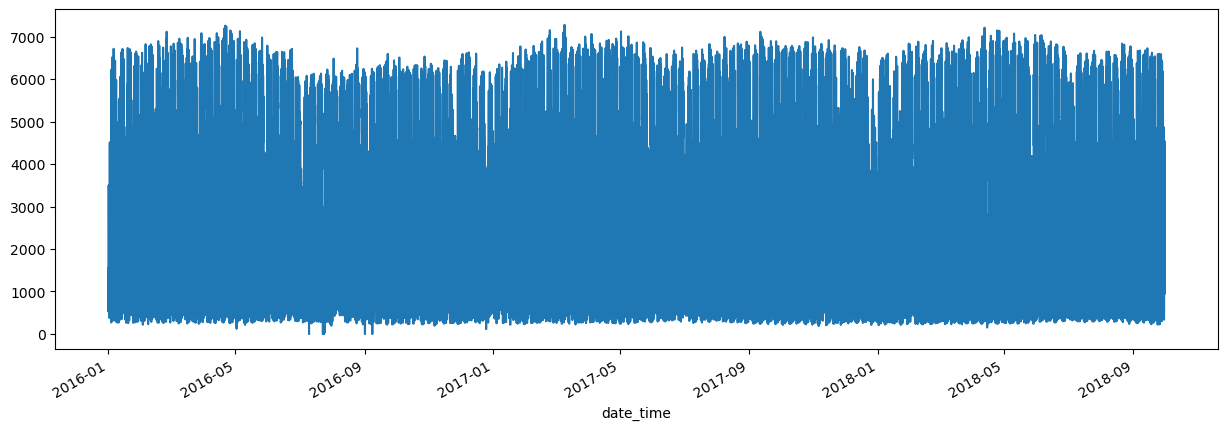

In [4]:
data.traffic_volume.plot(figsize=(15,5))

In [5]:
data['time']=pd.to_datetime(data.index).hour

In [6]:
data['day_of_week']=pd.to_datetime(data.index).dayofweek

In [7]:
feature_cols= ['temp', 'rain_1h', 'snow_1h', 'clouds_all', 'weather_main', 'time','day_of_week']

num_features = ['temp', 'rain_1h', 'snow_1h', 'clouds_all']
cat_features = ['weather_main', 'time','day_of_week']

In [8]:
X = data[feature_cols]
y= data.traffic_volume

In [9]:
X.loc[X.weather_main=='Squall','weather_main'] = 'Rain'

/Users/vanmagnan/opt/anaconda3/lib/python3.8/site-packages/pandas/core/indexing.py:1720: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_column(loc, value, pi)


In [10]:


# train / test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y)



In [11]:
numeric_processor = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
    ])
categorical_processor = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder())])

In [12]:
feature_processor = ColumnTransformer(
    transformers=[
        ('num', numeric_processor, num_features),
        ('cat', categorical_processor, cat_features)
    ],
         remainder='drop')

In [13]:

alpha = 0.3
max_iter = 10000

from sklearn.linear_model import Lasso


In [14]:
pipe = Pipeline(steps=[('preprocessor', feature_processor),
                           ('poly_features', PolynomialFeatures(degree=2)), # add polynomial combinations of the features
                           ('reg',Lasso(alpha=alpha, max_iter=max_iter))   
                          ])
pipe



Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['temp', 'rain_1h', 'snow_1h',
                                                   'clouds_all']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder())]),
                                                  ['weather_main', 'time',
                                                   'day_of_week'])])),
                ('poly_features', PolynomialFeatures()),
                ('reg', Lasso(alpha=0.3, max_iter=10000))])

In [15]:
pipe.fit(X_train,y_train)

/Users/vanmagnan/opt/anaconda3/lib/python3.8/site-packages/sklearn/linear_model/_coordinate_descent.py:592: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 1738355793.3335304, tolerance: 8157192.089940828
  model = cd_fast.sparse_enet_coordinate_descent(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['temp', 'rain_1h', 'snow_1h',
                                                   'clouds_all']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder())]),
                                                  ['weather_main', 'time',
                                                   'day_of_week'])])),
                ('poly_features', PolynomialFeatures()),
                ('reg', Lasso(alpha=0.3, max_iter=10000))])

In [16]:
y_test_pred = pipe.predict(X_test)

In [17]:


from sklearn.metrics import mean_squared_error
mean_squared_error(y_test, y_test_pred)



239878.95300748045

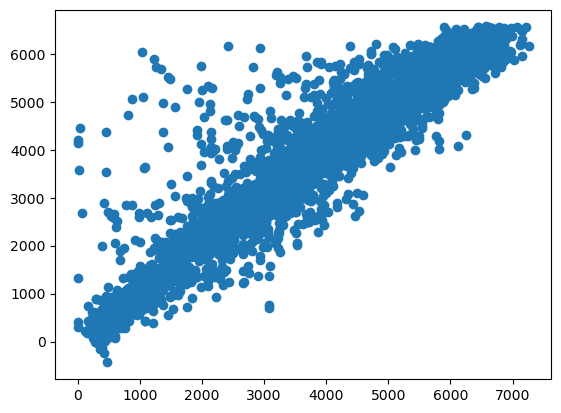

In [18]:
plt.scatter(y_test, y_test_pred)

In [19]:
# these look correlated, but I guess we can do a grid-search on alpha. this is gonna take a while

In [20]:
param_dict={'reg__alpha':[0.1,0.2,0.3,0.4,0.5,0.6],
           'poly_features__degree':[1,2]}

In [21]:
grid = GridSearchCV(pipe,
                   param_dict,
                   scoring='neg_mean_squared_error')

In [22]:
grid.fit(X_train,y_train)

/Users/vanmagnan/opt/anaconda3/lib/python3.8/site-packages/sklearn/linear_model/_coordinate_descent.py:592: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 1980395192.598756, tolerance: 6558075.137852045
  model = cd_fast.sparse_enet_coordinate_descent(
/Users/vanmagnan/opt/anaconda3/lib/python3.8/site-packages/sklearn/linear_model/_coordinate_descent.py:592: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 1836632473.427153, tolerance: 6534104.394842564
  model = cd_fast.sparse_enet_coordinate_descent(
/Users/vanmagnan/opt/anaconda3/lib/python3.8/site-packages/sklearn/linear_model/_coordinate_descent.py:592: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 1794420885.0908492, tolerance: 6526103.47754635
  model = cd_fast.sparse_enet_coordinate_descent(
/Users/vanmagnan/opt/anaconda3/lib/pytho

GridSearchCV(estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['temp',
                                                                          'rain_1h',
                                                                          'snow_1h',
                                                                          'clouds_all']),
                                                                        ('cat',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('encoder',
                                                                                          OneHotEncoder())]),
                                                                         ['weather_main',
                                                                          'time',
                                                                          'day_of_week'])])),
                                       ('poly_features', PolynomialFeatures()),
                                       ('reg',
                                        Lasso(alpha=0.3, max_iter=10000))]),
             param_grid={'poly_features__degree': [1, 2],
                         'reg__alpha': [0.1, 0.2, 0.3, 0.4, 0.5, 0.6]},
             scoring='neg_mean_squared_error')

In [24]:
best = grid.best_estimator_

In [25]:
y_test_pred = best.predict(X_test)
mean_squared_error(y_test, y_test_pred)

651328.7361552928

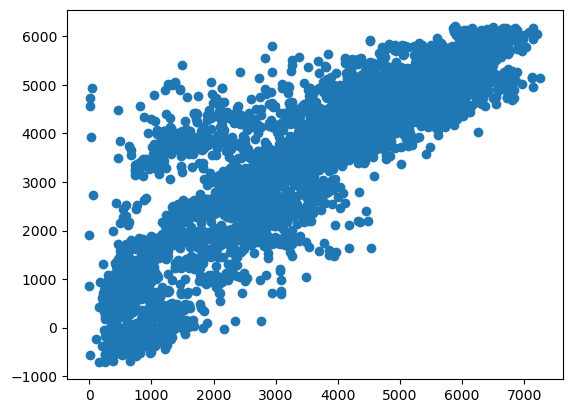

In [26]:
plt.scatter(y_test, y_test_pred)

maybe this is better?